# Logistic Regression from Scratch - Student Performance Prediction
**Implemented on the 300K cleaned dataset**  
We use the preprocessed files from `data_processing.ipynb`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_style("whitegrid")
print("Libraries imported!")

Libraries imported!


In [3]:
# Load the cleaned files we saved earlier
X = pd.read_csv('X_features.csv')
y = pd.read_csv('y_target.csv')

# Convert to numpy arrays (required for from-scratch implementation)
X = X.values.astype(float)
y = y.values.ravel().astype(float)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target unique values: {np.unique(y)}")

Feature matrix shape: (300000, 31)
Target shape: (300000,)
Target unique values: [0. 1.]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 240000
Testing samples: 60000


In [5]:
# Very important for gradient descent to converge
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1  # avoid division by zero

X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test  - mean) / std

print("✅ Features scaled successfully!")

✅ Features scaled successfully!


In [6]:
# Add column of 1s for the intercept (bias)
X_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_scaled  = np.c_[np.ones(X_test_scaled.shape[0]),  X_test_scaled]

print(f"New shape with bias term: {X_train_scaled.shape}")

New shape with bias term: (240000, 32)


In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [8]:
def compute_cost(X, y, theta, lambda_reg=0.0):
    m = len(y)
    h = sigmoid(X @ theta)
    cost = (-1/m) * np.sum(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10))
    
    # Optional L2 regularization
    if lambda_reg > 0:
        cost += (lambda_reg / (2 * m)) * np.sum(theta[1:] ** 2)
    
    return cost

In [9]:
def gradient_descent(X, y, theta, learning_rate=0.1, iterations=1000, lambda_reg=0.01):
    m = len(y)
    cost_history = []
    
    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))
        
        # Regularization (don't regularize bias term)
        if lambda_reg > 0:
            gradient[1:] += (lambda_reg / m) * theta[1:]
        
        theta = theta - learning_rate * gradient
        cost = compute_cost(X, y, theta, lambda_reg)
        cost_history.append(cost)
        
        if i % 200 == 0:
            print(f"Iteration {i} | Cost: {cost:.4f}")
    
    return theta, cost_history

In [10]:
# Initialize parameters
np.random.seed(42)
theta = np.zeros(X_train_scaled.shape[1])

# Train
theta, cost_history = gradient_descent(
    X=X_train_scaled,
    y=y_train,
    theta=theta,
    learning_rate=0.1,
    iterations=2000,      # increase if needed
    lambda_reg=0.01
)

print("\n✅ Training completed!")

Iteration 0 | Cost: 0.6797
Iteration 200 | Cost: 0.3158
Iteration 400 | Cost: 0.2941
Iteration 600 | Cost: 0.2877
Iteration 800 | Cost: 0.2852
Iteration 1000 | Cost: 0.2841
Iteration 1200 | Cost: 0.2835
Iteration 1400 | Cost: 0.2832
Iteration 1600 | Cost: 0.2830
Iteration 1800 | Cost: 0.2829

✅ Training completed!


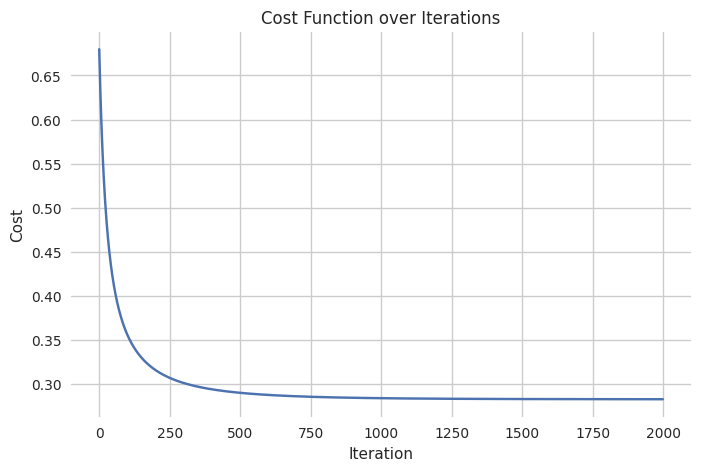

In [11]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.title('Cost Function over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

=== Test Set Performance ===
Accuracy : 0.8694
Precision: 0.8831
Recall   : 0.9027
F1 Score : 0.8928
ROC-AUC  : 0.9471


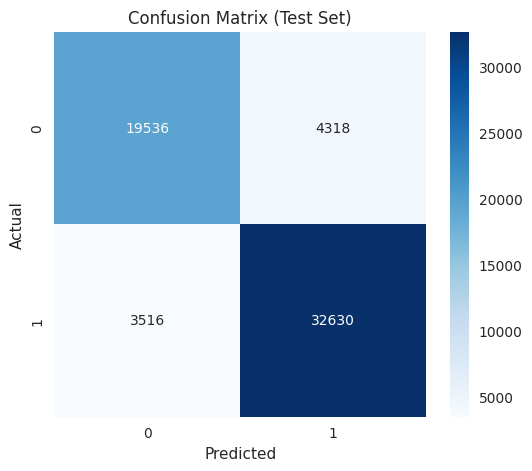

In [15]:
def predict(X, theta, threshold=0.5):
    probabilities = sigmoid(X @ theta)
    return (probabilities >= threshold).astype(int), probabilities

# Predict
y_pred_train, _ = predict(X_train_scaled, theta)
y_pred_test, y_prob_test = predict(X_test_scaled, theta)

# Metrics
print("=== Test Set Performance ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_test):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_test):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

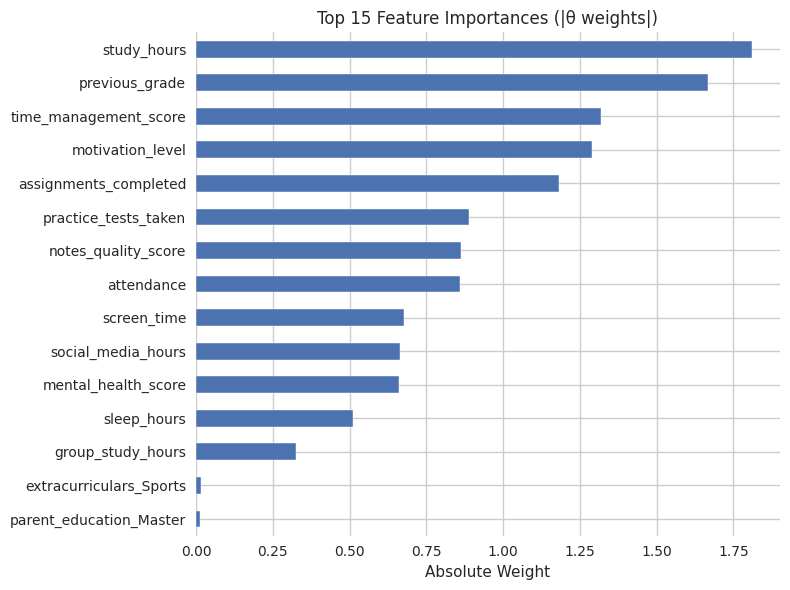

In [19]:
feature_names = pd.read_csv('X_features.csv').columns.tolist()
weights = pd.Series(np.abs(theta[1:]), index=feature_names).sort_values(ascending=True).tail(15)
plt.figure(figsize=(8,6))
weights.plot(kind='barh')
plt.title('Top 15 Feature Importances (|θ weights|)')
plt.xlabel('Absolute Weight')
plt.tight_layout()
plt.show()

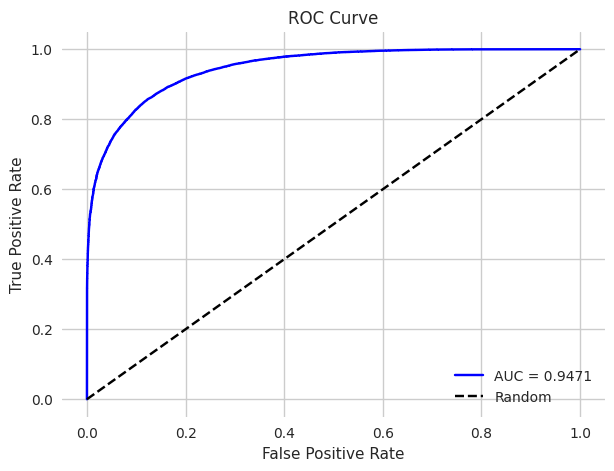

In [16]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_prob_test):.4f}')
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
#just for comparision
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(max_iter=2000, random_state=42)
sklearn_model.fit(X_train_scaled, y_train)
y_pred_sk = sklearn_model.predict(X_test_scaled)

print("sklearn Accuracy:", accuracy_score(y_test, y_pred_sk))

sklearn Accuracy: 0.8694833333333334


In [14]:
np.save('logistic_weights.npy', theta)
np.save('scaler_mean.npy', mean)
np.save('scaler_std.npy', std)

print("✅ Model weights and scaler saved!")

✅ Model weights and scaler saved!


In [ ]:
import json
from sklearn.metrics import roc_curve

# Save cost history
np.save('cost_history.npy', cost_history)

# Save metrics
metrics = {
    "accuracy":  float(accuracy_score(y_test, y_pred_test)),
    "precision": float(precision_score(y_test, y_pred_test)),
    "recall":    float(recall_score(y_test, y_pred_test)),
    "f1":        float(f1_score(y_test, y_pred_test)),
    "auc":       float(roc_auc_score(y_test, y_prob_test))
}
with open("model_metrics.json", "w") as f:
    json.dump(metrics, f)

# Save confusion matrix
np.save('conf_matrix.npy', cm)

# Save ROC curve data
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
np.save('fpr.npy', fpr)
np.save('tpr.npy', tpr)

print("✅ All evaluation files saved!")